In [16]:
%pip install --upgrade pip wheel
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 39.3 MB/s  0:00:00 eta 0:00:01
Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [12]:
import statsmodels, scipy
print("statsmodels:", statsmodels.__version__)
print("scipy:", scipy.__version__)

statsmodels: 0.14.5
scipy: 1.13.1


In [13]:
import pandas as pd

participants = ["KIN3", "KIN4", "KIN5"]

DT_APP = {
    "APP1": ["8:00", "10:38", "8:44"],
    "APP2": ["8:06", "10:14", "7:23"],
    "APP3": ["7:07", "9:17", "6:37"],
}
TT_APP = {
    "APP1": ["6:38", "10:17", "4:33"],
    "APP2": ["6:10", "7:35", "5:17"],
    "APP3": ["2:59", "7:55", "4:03"],
}

def mmss_to_seconds(mmss: str) -> int:
    m, s = mmss.split(":")
    return int(m) * 60 + int(s)

rows = []
for app_label, times in DT_APP.items():
    for p, t in zip(participants, times):
        rows.append({
            "participant": p,
            "method": "DT",
            "app": app_label,
            "time_str": t,
            "time_sec": mmss_to_seconds(t),
        })
for app_label, times in TT_APP.items():
    for p, t in zip(participants, times):
        rows.append({
            "participant": p,
            "method": "TT",
            "app": app_label,
            "time_str": t,
            "time_sec": mmss_to_seconds(t),
        })

df_app = pd.DataFrame(rows)[["participant", "method", "app", "time_str", "time_sec"]]
df_app


,participant,method,app,time_str,time_sec
0,KIN3,DT,APP1,8:00,480
1,KIN4,DT,APP1,10:38,638
2,KIN5,DT,APP1,8:44,524
3,KIN3,DT,APP2,8:06,486
4,KIN4,DT,APP2,10:14,614
5,KIN5,DT,APP2,7:23,443
6,KIN3,DT,APP3,7:07,427
7,KIN4,DT,APP3,9:17,557
8,KIN5,DT,APP3,6:37,397
9,KIN3,TT,APP1,6:38,398


In [14]:
import numpy as np

# Ensure df_app exists (run your data-prep cell first)
# Build plot_data: list of tuples (app, method, mean_val, indiv_vals)
apps = ["APP1", "APP2", "APP3"]
methods = ["DT", "TT"]

plot_data = []
for app in apps:
    for method in methods:
        vals = df_app.loc[(df_app["app"]==app) & (df_app["method"]==method), "time_sec"].to_numpy()
        mean_val = float(vals.mean())
        plot_data.append((app, method, mean_val, vals))


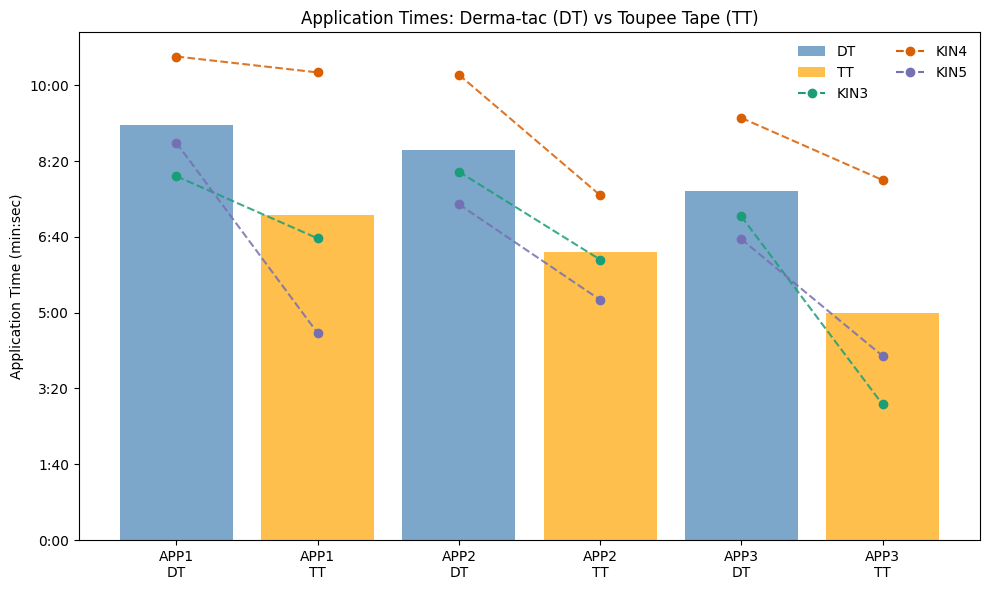

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# Bar color
colors = {"DT": "steelblue", "TT": "orange"}

# Participant colors (dots + lines) — order must match indiv_vals order in plot_data
participants = ["KIN3", "KIN4", "KIN5"]
participant_colors = {
    "KIN3": "#1b9e77",
    "KIN4": "#d95f02",
    "KIN5": "#7570b3",
}

def seconds_to_mmss(y, _pos=None):
    y = int(round(y))
    m, s = divmod(y, 60)
    return f"{m}:{s:02d}"

fig, ax = plt.subplots(figsize=(10, 6))
bar_positions = np.arange(len(plot_data))
bar_width = 0.8

last_dt_vals = None

for i, (app, method, mean_val, indiv_vals) in enumerate(plot_data):
    # bars (means)
    ax.bar(i, mean_val, color=colors[method], width=bar_width, alpha=0.7)

    # dots
    for p_idx, val in enumerate(indiv_vals):
        p_id = participants[p_idx]
        ax.scatter(i, val, color=participant_colors[p_id], zorder=10)

    # connect DT -> TT within same APP
    if method == "DT":
        last_dt_vals = indiv_vals
    else:
        if last_dt_vals is not None:
            for p_idx, (dt_v, tt_v) in enumerate(zip(last_dt_vals, indiv_vals)):
                p_id = participants[p_idx]
                ax.plot([i-1, i], [dt_v, tt_v],
                        color=participant_colors[p_id], linestyle="--", alpha=0.85)

# x labels
ax.set_xticks(bar_positions)
ax.set_xticklabels([f"{app}\n{method}" for app, method, _, _ in plot_data])

# y axis in mm:ss
ax.yaxis.set_major_formatter(FuncFormatter(seconds_to_mmss))
ax.set_ylabel("Application Time (min:sec)")
ax.set_title("Application Times: Derma-tac (DT) vs Toupee Tape (TT)")

# legends
method_handles = [
    Patch(facecolor=colors["DT"], edgecolor="none", alpha=0.7, label="DT"),
    Patch(facecolor=colors["TT"], edgecolor="none", alpha=0.7, label="TT"),
]
participant_handles = [
    Line2D([0], [0], color=participant_colors["KIN3"], linestyle="--", marker="o", label="KIN3"),
    Line2D([0], [0], color=participant_colors["KIN4"], linestyle="--", marker="o", label="KIN4"),
    Line2D([0], [0], color=participant_colors["KIN5"], linestyle="--", marker="o", label="KIN5"),
]
ax.legend(handles=method_handles + participant_handles, frameon=False, ncol=2)

plt.tight_layout()
plt.show()



Collapsed Paired Test (TT vs DT):
Mean TT–DT difference = -137.67 sec (-2:18)
  Paired t-test p = 0.0006


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_25531/1357877263.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([sec_to_mmss(y) for y in y_ticks])


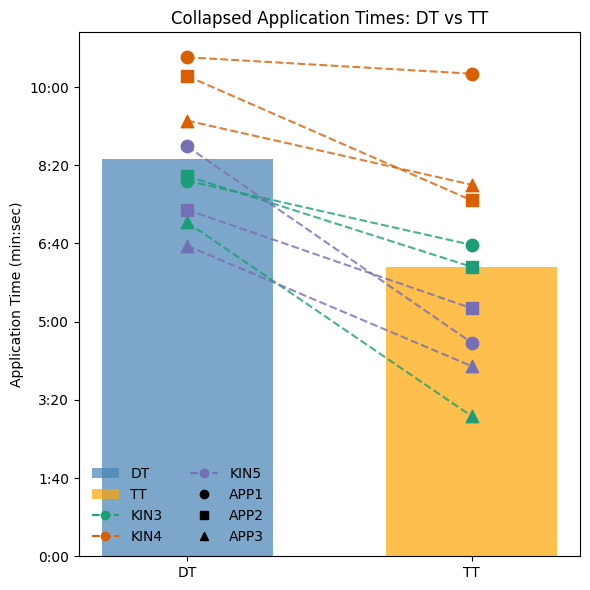

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

# --- Collapsed paired test ---
pairs_dt = []
pairs_tt = []
for p in participants:
    for app_i in [1,2,3]:
        dt = df[(df.participant==p)&(df.method=="DT")&(df.app_index==app_i)].time_sec.iloc[0]
        tt = df[(df.participant==p)&(df.method=="TT")&(df.app_index==app_i)].time_sec.iloc[0]
        pairs_dt.append(dt)
        pairs_tt.append(tt)

tval, pval = stats.ttest_rel(pairs_tt, pairs_dt)
mean_diff = np.mean(np.array(pairs_tt) - np.array(pairs_dt))

def sec_to_mmss(sec):
    m,s = divmod(int(round(sec)),60)
    return f"{m}:{s:02d}"

print("Collapsed Paired Test (TT vs DT):")
print("Mean TT–DT difference =", f"{mean_diff:.2f}", "sec",
      f"({sec_to_mmss_signed(mean_diff)})")

print(f"  Paired t-test p = {pval:.4f}")

# --- Collapsed plot ---
collapsed_means = df.groupby("method")["time_sec"].mean()

participant_colors = {"KIN3":"#1b9e77","KIN4":"#d95f02","KIN5":"#7570b3"}
app_markers = {1:"o", 2:"s", 3:"^"}

fig, ax = plt.subplots(figsize=(6,6))

# Bar plot of means
ax.bar([0,1], collapsed_means, color=["steelblue","orange"], alpha=0.7, width=0.6)

# Overlay points and connect
for p in participants:
    for app_i in [1,2,3]:
        dt = df[(df.participant==p)&(df.method=="DT")&(df.app_index==app_i)].time_sec.iloc[0]
        tt = df[(df.participant==p)&(df.method=="TT")&(df.app_index==app_i)].time_sec.iloc[0]
        color = participant_colors[p]
        marker = app_markers[app_i]
        ax.scatter(0, dt, color=color, marker=marker, s=80, zorder=10)
        ax.scatter(1, tt, color=color, marker=marker, s=80, zorder=10)
        ax.plot([0,1], [dt, tt], color=color, linestyle="--", alpha=0.8)

# X labels
ax.set_xticks([0,1])
ax.set_xticklabels(["DT","TT"])

# Y axis in mm:ss
y_ticks = ax.get_yticks()
ax.set_yticklabels([sec_to_mmss(y) for y in y_ticks])
ax.set_ylabel("Application Time (min:sec)")
ax.set_title("Collapsed Application Times: DT vs TT")

# Legend
method_handles = [
    Patch(facecolor="steelblue", alpha=0.7, label="DT"),
    Patch(facecolor="orange", alpha=0.7, label="TT"),
]
participant_handles = [
    Line2D([0],[0], color=participant_colors["KIN3"], linestyle="--", marker="o", label="KIN3"),
    Line2D([0],[0], color=participant_colors["KIN4"], linestyle="--", marker="o", label="KIN4"),
    Line2D([0],[0], color=participant_colors["KIN5"], linestyle="--", marker="o", label="KIN5"),
]
app_handles = [
    Line2D([0],[0], color="black", marker="o", linestyle="None", label="APP1"),
    Line2D([0],[0], color="black", marker="s", linestyle="None", label="APP2"),
    Line2D([0],[0], color="black", marker="^", linestyle="None", label="APP3"),
]

ax.legend(handles=method_handles+participant_handles+app_handles,
          frameon=False, ncol=2)

plt.tight_layout()
plt.show()


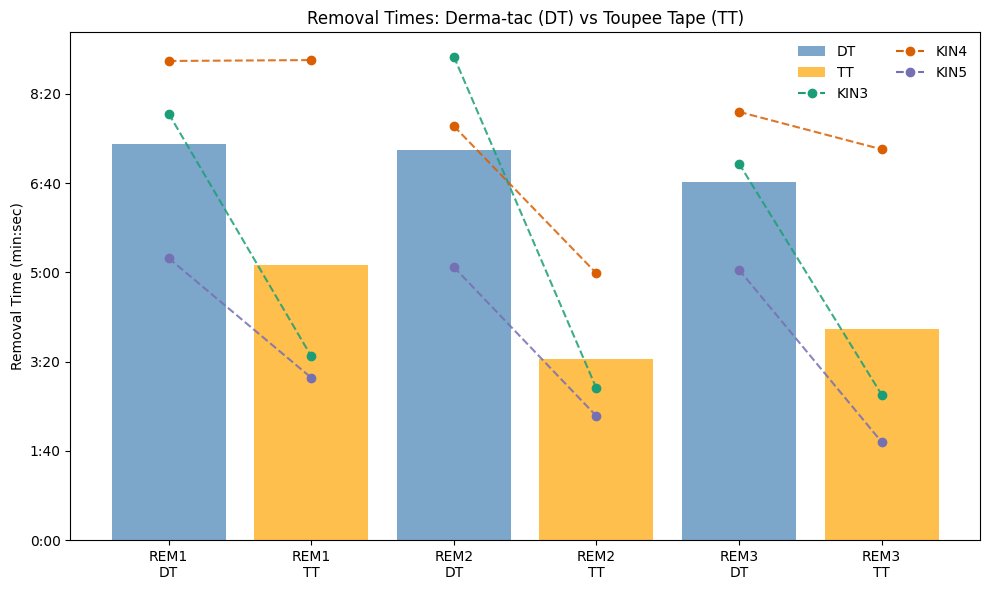

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# --- Raw REM data (min:sec) ---
DT_REM = {
    "REM1": ["7:58", "8:57", "5:16"],
    "REM2": ["9:02", "7:44", "5:06"],
    "REM3": ["7:02", "8:00", "5:03"],
}
TT_REM = {
    "REM1": ["3:26", "8:58", "3:02"],
    "REM2": ["2:50", "4:59", "2:19"],
    "REM3": ["2:43", "7:18", "1:50"],
}

def mmss_to_seconds(mmss):
    m, s = map(int, mmss.split(":"))
    return m*60 + s

def sec_to_mmss(sec):
    sign = "-" if sec < 0 else ""
    sec = abs(int(round(sec)))
    m,s = divmod(sec,60)
    return f"{sign}{m}:{s:02d}"

# Build tidy dataframe
rows = []
for method, rem_dict in [("DT", DT_REM), ("TT", TT_REM)]:
    for rem_i, (rem_label, times) in enumerate(rem_dict.items(), start=1):
        for p, t in zip(participants, times):
            rows.append({
                "participant": p,
                "method": method,
                "rem_index": rem_i,
                "rem_label": rem_label,
                "time_sec": mmss_to_seconds(t),
                "time_str": t
            })
df_rem = pd.DataFrame(rows)

# Prepare plot_data: list of (REM, method, mean, indiv_vals)
plot_data = []
for rem_label in ["REM1","REM2","REM3"]:
    for method in ["DT","TT"]:
        vals = df_rem.loc[(df_rem["rem_label"]==rem_label)&(df_rem["method"]==method),"time_sec"].to_numpy()
        mean_val = float(vals.mean())
        plot_data.append((rem_label, method, mean_val, vals))

# --- Plotting ---
colors = {"DT": "steelblue", "TT": "orange"}
participant_colors = {"KIN3":"#1b9e77","KIN4":"#d95f02","KIN5":"#7570b3"}

fig, ax = plt.subplots(figsize=(10,6))
bar_positions = np.arange(len(plot_data))
bar_width = 0.8
last_dt_vals = None

for i, (rem_label, method, mean_val, indiv_vals) in enumerate(plot_data):
    # bar
    ax.bar(i, mean_val, color=colors[method], width=bar_width, alpha=0.7)

    # dots
    for p_idx, val in enumerate(indiv_vals):
        p_id = participants[p_idx]
        ax.scatter(i, val, color=participant_colors[p_id], zorder=10)

    # connect DT→TT
    if method=="DT":
        last_dt_vals = indiv_vals
    else:
        for p_idx, (dt_v, tt_v) in enumerate(zip(last_dt_vals, indiv_vals)):
            p_id = participants[p_idx]
            ax.plot([i-1,i], [dt_v,tt_v],
                    color=participant_colors[p_id], linestyle="--", alpha=0.85)

# x-axis labels
ax.set_xticks(bar_positions)
ax.set_xticklabels([f"{rem}\n{method}" for rem, method, _, _ in plot_data])

# y-axis as mm:ss
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: sec_to_mmss(y)))
ax.set_ylabel("Removal Time (min:sec)")
ax.set_title("Removal Times: Derma-tac (DT) vs Toupee Tape (TT)")

# legend
method_handles = [
    Patch(facecolor=colors["DT"], alpha=0.7, label="DT"),
    Patch(facecolor=colors["TT"], alpha=0.7, label="TT"),
]
participant_handles = [
    Line2D([0],[0], color=participant_colors["KIN3"], linestyle="--", marker="o", label="KIN3"),
    Line2D([0],[0], color=participant_colors["KIN4"], linestyle="--", marker="o", label="KIN4"),
    Line2D([0],[0], color=participant_colors["KIN5"], linestyle="--", marker="o", label="KIN5"),
]
ax.legend(handles=method_handles+participant_handles, frameon=False, ncol=2)

plt.tight_layout()
plt.show()


Collapsed Paired Test (REM: TT vs DT):
  Mean TT–DT difference = -178.11 sec (-2:58)
  Paired t-test p = 0.0017


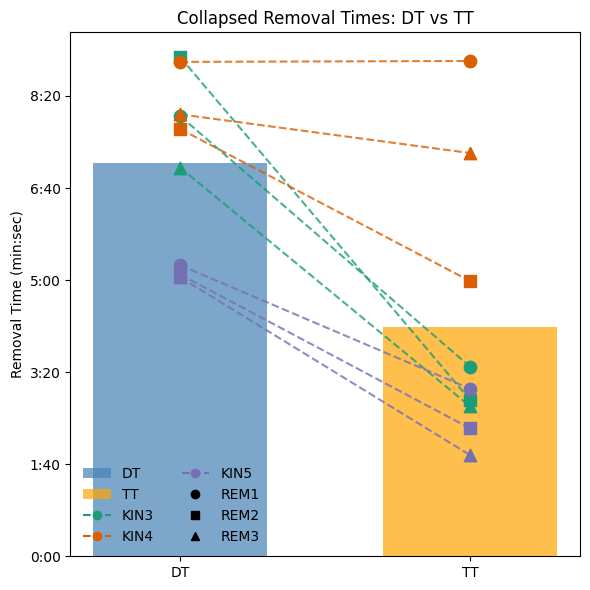

In [22]:
# === Collapsed REM paired test + collapsed plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from scipy import stats

# ---------- Helpers ----------
def mmss_to_seconds(mmss):
    m, s = map(int, mmss.split(":"))
    return m*60 + s

def sec_to_mmss_signed(sec):
    sign = "-" if sec < 0 else ""
    sec = int(round(abs(sec)))
    m, s = divmod(sec, 60)
    return f"{sign}{m}:{s:02d}"

# ---------- Participants + colors (reuse if already defined) ----------
participants = ["KIN3", "KIN4", "KIN5"]
participant_colors = {"KIN3":"#1b9e77","KIN4":"#d95f02","KIN5":"#7570b3"}
rem_markers = {1:"o", 2:"s", 3:"^"}  # REM1 circle, REM2 square, REM3 triangle

# ---------- Raw REM data (delete if df_rem already exists) ----------
DT_REM = {
    "REM1": ["7:58", "8:57", "5:16"],
    "REM2": ["9:02", "7:44", "5:06"],
    "REM3": ["7:02", "8:00", "5:03"],
}
TT_REM = {
    "REM1": ["3:26", "8:58", "3:02"],
    "REM2": ["2:50", "4:59", "2:19"],
    "REM3": ["2:43", "7:18", "1:50"],
}

# Build tidy df_rem (delete this block if you already have df_rem)
rows = []
for method, rem_dict in [("DT", DT_REM), ("TT", TT_REM)]:
    for rem_i, (rem_label, times) in enumerate(rem_dict.items(), start=1):
        for p, t in zip(participants, times):
            rows.append({
                "participant": p,
                "method": method,
                "rem_index": rem_i,     # 1..3
                "rem_label": rem_label, # "REM1".."REM3"
                "time_sec": mmss_to_seconds(t),
                "time_str": t
            })
df_rem = pd.DataFrame(rows)

# ---------- Collapsed paired test (TT vs DT across all 9 pairs) ----------
pairs_dt = []
pairs_tt = []
for p in participants:
    for rem_i in [1,2,3]:
        dt = df_rem[(df_rem.participant==p)&(df_rem.method=="DT")&(df_rem.rem_index==rem_i)].time_sec.iloc[0]
        tt = df_rem[(df_rem.participant==p)&(df_rem.method=="TT")&(df_rem.rem_index==rem_i)].time_sec.iloc[0]
        pairs_dt.append(dt)
        pairs_tt.append(tt)

tval, pval = stats.ttest_rel(pairs_tt, pairs_dt)
mean_diff = float(np.mean(np.array(pairs_tt) - np.array(pairs_dt)))

print("Collapsed Paired Test (REM: TT vs DT):")
print(f"  Mean TT–DT difference = {mean_diff:.2f} sec ({sec_to_mmss_signed(mean_diff)})")
print(f"  Paired t-test p = {pval:.4f}")

# ---------- Collapsed means for bars ----------
collapsed_means = df_rem.groupby("method")["time_sec"].mean()
methods = ["DT","TT"]
bar_colors = {"DT": "steelblue", "TT": "orange"}

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6,6))

# Bars
ax.bar([0,1], [collapsed_means[m] for m in methods],
       color=[bar_colors[m] for m in methods],
       alpha=0.7, width=0.6)

# Overlay points and connect lines
for p in participants:
    for rem_i in [1,2,3]:
        dt = df_rem[(df_rem.participant==p)&(df_rem.method=="DT")&(df_rem.rem_index==rem_i)].time_sec.iloc[0]
        tt = df_rem[(df_rem.participant==p)&(df_rem.method=="TT")&(df_rem.rem_index==rem_i)].time_sec.iloc[0]
        color = participant_colors[p]
        marker = rem_markers[rem_i]
        ax.scatter(0, dt, color=color, marker=marker, s=80, zorder=10)
        ax.scatter(1, tt, color=color, marker=marker, s=80, zorder=10)
        ax.plot([0,1], [dt, tt], color=color, linestyle="--", alpha=0.8)

# Axes and labels
ax.set_xticks([0,1])
ax.set_xticklabels(["DT","TT"])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: sec_to_mmss_signed(y)))
ax.set_ylabel("Removal Time (min:sec)")
ax.set_title("Collapsed Removal Times: DT vs TT")

# Legend: methods, participants, and REM markers
method_handles = [
    Patch(facecolor=bar_colors["DT"], alpha=0.7, label="DT"),
    Patch(facecolor=bar_colors["TT"], alpha=0.7, label="TT"),
]
participant_handles = [
    Line2D([0],[0], color=participant_colors["KIN3"], linestyle="--", marker="o", label="KIN3"),
    Line2D([0],[0], color=participant_colors["KIN4"], linestyle="--", marker="o", label="KIN4"),
    Line2D([0],[0], color=participant_colors["KIN5"], linestyle="--", marker="o", label="KIN5"),
]
rem_handles = [
    Line2D([0],[0], color="black", marker="o", linestyle="None", label="REM1"),
    Line2D([0],[0], color="black", marker="s", linestyle="None", label="REM2"),
    Line2D([0],[0], color="black", marker="^", linestyle="None", label="REM3"),
]

ax.legend(handles=method_handles + participant_handles + rem_handles,
          frameon=False, ncol=2)

plt.tight_layout()
plt.show()


In [27]:
import statsmodels.formula.api as smf

def sec_to_mmss(sec):
    m, s = divmod(int(round(sec)), 60)
    return f"{m}:{s:02d}"

# Recode so APP1=0, APP2=1, APP3=2
df = df.copy()
df["app_index0"] = df["app_index"] - 1

def run_lme_rand_intercept(method):
    d = df[df.method==method]

    # Random intercept for participants
    md = smf.mixedlm("time_sec ~ app_index0", d, groups=d["participant"])
    mdf = md.fit(reml=True, method="lbfgs", disp=False)

    slope = mdf.params["app_index0"]
    pval = mdf.pvalues["app_index0"]

    print(f"\n=== {method} ===")
    print(f"Slope (learning rate): {slope:.2f} sec/app ({sec_to_mmss(slope)}/app)")
    print(f"p-value for slope: {pval:.4f}")

    return mdf

mdf_DT = run_lme_rand_intercept("DT")
mdf_TT = run_lme_rand_intercept("TT")



=== DT ===
Slope (learning rate): -43.50 sec/app (-1:16/app)
p-value for slope: 0.0000

=== TT ===
Slope (learning rate): -65.17 sec/app (-2:55/app)
p-value for slope: 0.0145


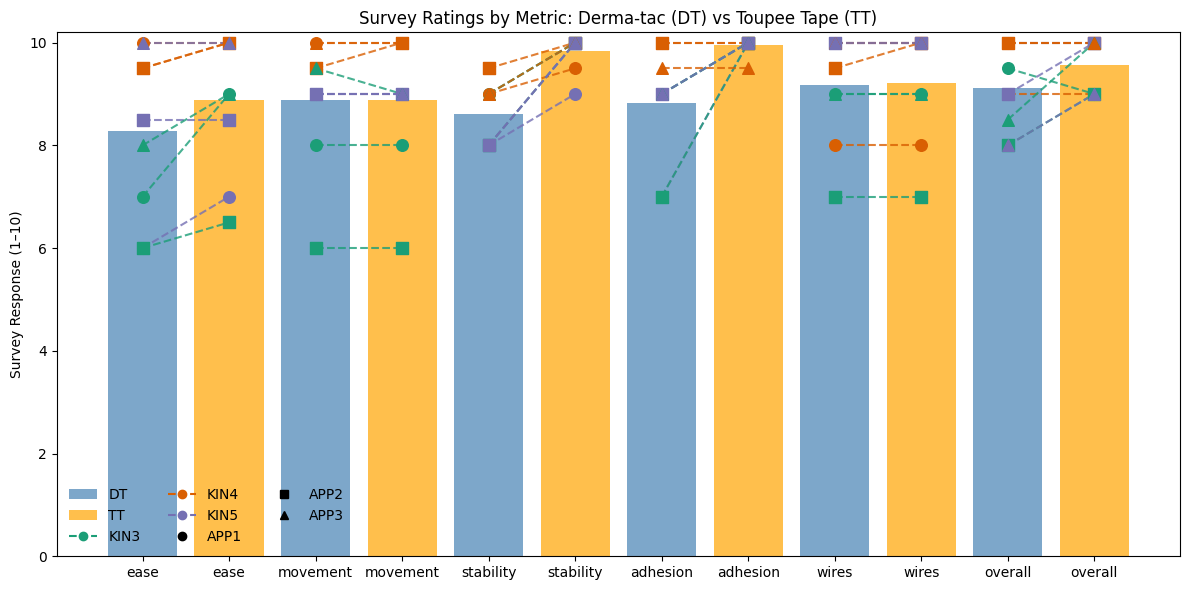

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------- Raw ratings ----------
# Order of participants per row: [KIN3, KIN4, KIN5]
# We'll concatenate APP1, APP2, APP3 to form the 9 points per metric×method

DT = {
    "ease": {
        1: [7, 10, 6],
        2: [6, 9.5, 8.5],
        3: [8, 9.5, 10],
    },
    "movement": {
        1: [8, 10, 9],
        2: [6, 9.5, 9],
        3: [9.5, 10, 9],
    },
    "stability": {
        1: [9, 9, 8],
        2: [8, 9.5, 8],
        3: [9, 9, 8],
    },
    "adhesion": {
        1: [9, 10, 7],
        2: [7, 10, 9],
        3: [9, 9.5, 9],
    },
    "wires": {
        1: [9, 8, 10],
        2: [7, 9.5, 10],
        3: [9, 10, 10],
    },
    "overall": {
        1: [9.5, 9, 10],
        2: [8, 10, 9],
        3: [8.5, 10, 8],
    },
}

TT = {
    "ease": {
        1: [9, 10, 7],
        2: [6.5, 10, 8.5],
        3: [9, 10, 10],
    },
    "movement": {
        1: [8, 10, 9],
        2: [6, 10, 9],
        3: [9, 10, 9],
    },
    "stability": {
        1: [10, 9.5, 9],
        2: [10, 10, 10],
        3: [10, 10, 10],
    },
    "adhesion": {
        1: [10, 10, 10],
        2: [10, 10, 10],
        3: [10, 9.5, 10],
    },
    "wires": {
        1: [9, 8, 10],
        2: [7, 10, 10],
        3: [9, 10, 10],
    },
    "overall": {
        1: [9, 9, 10],
        2: [9, 10, 10],
        3: [10, 10, 9],
    },
}

metrics_order = ["ease", "movement", "stability", "adhesion", "wires", "overall"]
participants = ["KIN3", "KIN4", "KIN5"]
participant_colors = {"KIN3":"#1b9e77","KIN4":"#d95f02","KIN5":"#7570b3"}
app_markers = {1:"o", 2:"s", 3:"^"}  # APP1 circle, APP2 square, APP3 triangle
method_bar_colors = {"DT": "steelblue", "TT": "orange"}

# ---------- Build tidy DataFrame ----------
rows = []
for method_name, block in [("DT", DT), ("TT", TT)]:
    for metric in metrics_order:
        for app_i in [1, 2, 3]:
            vals = block[metric][app_i]
            for p_idx, p in enumerate(participants):
                rows.append({
                    "method": method_name,
                    "metric": metric,
                    "app_index": app_i,              # 1..3
                    "participant": p,
                    "rating": float(vals[p_idx]),
                })
df_rate = pd.DataFrame(rows)

# ---------- Prepare means for bars ----------
means = (df_rate
         .groupby(["metric", "method"], as_index=False)["rating"]
         .mean()
         .rename(columns={"rating":"mean_rating"}))

# Bar x positions: for each metric, DT then TT
x_pairs = []
for m in metrics_order:
    x_pairs.extend([(m, "DT"), (m, "TT")])

x = np.arange(len(x_pairs))

# Quick lookup for means
mean_map = {(r["metric"], r["method"]): r["mean_rating"] for _, r in means.iterrows()}

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8

# Bars
for i, (metric, method) in enumerate(x_pairs):
    ax.bar(i, mean_map[(metric, method)], color=method_bar_colors[method],
           width=bar_width, alpha=0.7)

# Overlay 9 dots per (metric, method), colored by participant and marker by APP,
# and connect each dot to the TT counterpart (same metric, same participant, same APP)
for metric in metrics_order:
    x_dt = x_pairs.index((metric, "DT"))
    x_tt = x_pairs.index((metric, "TT"))

    for app_i in [1,2,3]:
        # ratings per participant (in KIN3, KIN4, KIN5 order)
        dt_vals = df_rate[(df_rate.metric==metric)&(df_rate.method=="DT")&(df_rate.app_index==app_i)].sort_values("participant")["rating"].to_numpy()
        tt_vals = df_rate[(df_rate.metric==metric)&(df_rate.method=="TT")&(df_rate.app_index==app_i)].sort_values("participant")["rating"].to_numpy()

        for p_idx, p in enumerate(participants):
            color = participant_colors[p]
            marker = app_markers[app_i]
            dt_v = dt_vals[p_idx]
            tt_v = tt_vals[p_idx]

            # dots
            ax.scatter(x_dt, dt_v, color=color, marker=marker, s=70, zorder=10)
            ax.scatter(x_tt, tt_v, color=color, marker=marker, s=70, zorder=10)

            # connection line
            ax.plot([x_dt, x_tt], [dt_v, tt_v], color=color, linestyle="--", alpha=0.8)

# Aesthetics
ax.set_xticks(x)
ax.set_xticklabels([m for (m, _) in x_pairs], rotation=0)
ax.set_ylim(0, 10.2)
ax.set_ylabel("Survey Response (1–10)")
ax.set_title("Survey Ratings by Metric: Derma-tac (DT) vs Toupee Tape (TT)")

# Legends
method_handles = [
    Patch(facecolor=method_bar_colors["DT"], alpha=0.7, label="DT"),
    Patch(facecolor=method_bar_colors["TT"], alpha=0.7, label="TT"),
]
participant_handles = [
    Line2D([0],[0], color=participant_colors["KIN3"], linestyle="--", marker="o", label="KIN3"),
    Line2D([0],[0], color=participant_colors["KIN4"], linestyle="--", marker="o", label="KIN4"),
    Line2D([0],[0], color=participant_colors["KIN5"], linestyle="--", marker="o", label="KIN5"),
]
app_handles = [
    Line2D([0],[0], color="black", marker=app_markers[1], linestyle="None", label="APP1"),
    Line2D([0],[0], color="black", marker=app_markers[2], linestyle="None", label="APP2"),
    Line2D([0],[0], color="black", marker=app_markers[3], linestyle="None", label="APP3"),
]

ax.legend(handles=method_handles + participant_handles + app_handles,
          frameon=False, ncol=3)

plt.tight_layout()
plt.show()
